In [1]:
# MLCB Assignment 1 - Task 4: Hyperparameter Tuning and Final Evaluation

%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import joblib  # in order to save the best_model.pkl

sys.path.append(os.path.abspath('..'))

from src.functions import (
    load_data,
    get_feature_matrix_target_and_features,
    split_stratified_data,
    build_num_preprocessor,
    evaluate_model_bootstrapping_eval_set,
    build_results_table_eval,
    get_comparison_boxplot,
    randomized_search_tune,
)

from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet, BayesianRidge
from sklearn.svm import SVR
from mrmr import mrmr_regression

In [ ]:
# load the data
df_development = load_data('../data/development_data.csv')
df_evaluation  = load_data('../data/evaluation_data.csv')

target_column = "age"
first_column_name = df_development.columns[0]
df_development.set_index(first_column_name, inplace=True)
df_evaluation.set_index(df_evaluation.columns[0], inplace=True)

X, y, cpg_features, cat_features = get_feature_matrix_target_and_features(df_development, target_column)

# Train/val split in order to perform the mRMR feature selection again
X_train, X_val, y_train, y_val = split_stratified_data(X, y, n_bins=5, test_size=0.2, random_state=42)
X_train_num = X_train[cpg_features]
X_val_num   = X_val[cpg_features]

num_preprocessor = build_num_preprocessor()
X_num_preprocessed = num_preprocessor.fit_transform(X_train_num)
X_num_df = pd.DataFrame(X_num_preprocessed, columns=cpg_features, index=X_train_num.index)

# we obtain again the mRMR features (same K=197, same training data as in task3 -> same result)
K_best = 197
cpg_mrmr_features = mrmr_regression(X=X_num_df, y=y_train, K=K_best)

# Full development set on the mRMR feature set 
X_dev = X[cpg_mrmr_features]   # raw
y_dev = y

# Evaluation set on the mRMR feature set
X_eval, y_eval, _, _ = get_feature_matrix_target_and_features(df_evaluation, target_column)
X_eval_num = X_eval[cpg_mrmr_features]

100%|██████████| 197/197 [00:20<00:00,  9.46it/s]


In [3]:
print(f"Final mRMR features (K={K_best}): {cpg_mrmr_features}")
print(f"Number of features selected: {len(cpg_mrmr_features)}")
print(f"Shape of development set: {X_dev.shape}")
print(f"Shape of evaluation set: {X_eval_num.shape}")


Final mRMR features (K=197): ['cg16867657', 'cg06639320', 'cg10501210', 'cg24724428', 'cg22454769', 'cg21572722', 'cg06784991', 'cg01974375', 'cg07553761', 'cg07082267', 'cg24079702', 'cg19283806', 'cg14692377', 'cg08097417', 'cg22796704', 'cg08160331', 'cg08234504', 'cg14361627', 'cg16008966', 'cg04875128', 'cg16932827', 'cg07547549', 'cg09809672', 'cg02650266', 'cg23744638', 'cg07583137', 'cg22736354', 'cg03259243', 'cg06240854', 'cg24466241', 'cg17183905', 'cg01763090', 'cg22285878', 'cg23500537', 'cg23078123', 'cg17110586', 'cg11176990', 'cg10149533', 'cg16419235', 'cg15804973', 'cg01554474', 'cg07502389', 'cg22158769', 'cg22156456', 'cg00292135', 'cg25994988', 'cg00748589', 'cg03473532', 'cg18933331', 'cg03607117', 'cg08262002', 'cg09168222', 'cg27320127', 'cg16054275', 'cg01528542', 'cg06685111', 'cg11693709', 'cg24436906', 'cg02228185', 'cg21567504', 'cg26153045', 'cg09124496', 'cg20273670', 'cg03032497', 'cg04999352', 'cg17621438', 'cg06493994', 'cg07158339', 'cg07955995', 'cg2

In [5]:
# Hyperparameter Tuning with RandomizedSearchCV 

# ElasticNet
best_elasticnet, best_params_en, cv_results_en = randomized_search_tune(
    model_name='ElasticNet',
    model=ElasticNet(),
    X_dev=X_dev,
    y_dev=y_dev,
    n_iter=40,
    cv=5,
    random_state=42
)

# SVR
best_svr, best_params_svr, cv_results_svr = randomized_search_tune(
    model_name='SVR',
    model=SVR(),
    X_dev=X_dev,
    y_dev=y_dev,
    n_iter=40,
    cv=5,
    random_state=42
)

# BayesianRidge
best_bayesianridge, best_params_br, cv_results_br = randomized_search_tune(
    model_name='BayesianRidge',
    model=BayesianRidge(),
    X_dev=X_dev,
    y_dev=y_dev,
    n_iter=40,
    cv=5,
    random_state=42
)

Fitting 5 folds for each of 40 candidates, totalling 200 fits

ElasticNet — Best parameters: {'model__alpha': np.float64(0.2801635158716261), 'model__l1_ratio': np.float64(0.22554447458683766)}
ElasticNet — Best CV RMSE: 4.6556
Fitting 5 folds for each of 40 candidates, totalling 200 fits

SVR — Best parameters: {'model__C': np.float64(51.006278059799115), 'model__epsilon': 0.01, 'model__kernel': 'rbf'}
SVR — Best CV RMSE: 5.2898
Fitting 5 folds for each of 40 candidates, totalling 200 fits

BayesianRidge — Best parameters: {'model__alpha_1': np.float64(3.798214508453255e-07), 'model__alpha_2': np.float64(9.074256288983855e-06), 'model__lambda_1': np.float64(0.0008761971101023686), 'model__lambda_2': np.float64(9.294394155644988e-07)}
BayesianRidge — Best CV RMSE: 4.6513


In [6]:
# Final model evaluation

# predictions on evaluation set
y_pred_en  = best_elasticnet.predict(X_eval_num)
y_pred_svr = best_svr.predict(X_eval_num)
y_pred_br  = best_bayesianridge.predict(X_eval_num)

# bootstrap evaluation
en_eval_results,  en_eval_dict  = evaluate_model_bootstrapping_eval_set(y_eval, y_pred_en,  n_bootstraps=1000, random_state=42)
svr_eval_results, svr_eval_dict = evaluate_model_bootstrapping_eval_set(y_eval, y_pred_svr, n_bootstraps=1000, random_state=42)
br_eval_results,  br_eval_dict  = evaluate_model_bootstrapping_eval_set(y_eval, y_pred_br,  n_bootstraps=1000, random_state=42)

# results table
eval_table = build_results_table_eval({
    'ElasticNet':    en_eval_results,
    'SVR':           svr_eval_results,
    'BayesianRidge': br_eval_results,
}, stage='FS+Tuned')

display(eval_table)


,Stage,RMSE (mean),RMSE (std),95% CI,MAE,R²,Pearson r
Model,,,,,,,
ElasticNet,FS+Tuned,4.9888,0.7376,"[3.7440, 6.6053]",3.4449,0.8712,0.9354
SVR,FS+Tuned,5.5133,0.6156,"[4.4158, 6.8250]",4.1296,0.8449,0.9220
BayesianRidge,FS+Tuned,4.9762,0.7048,"[3.7717, 6.5014]",3.4961,0.8721,0.9366


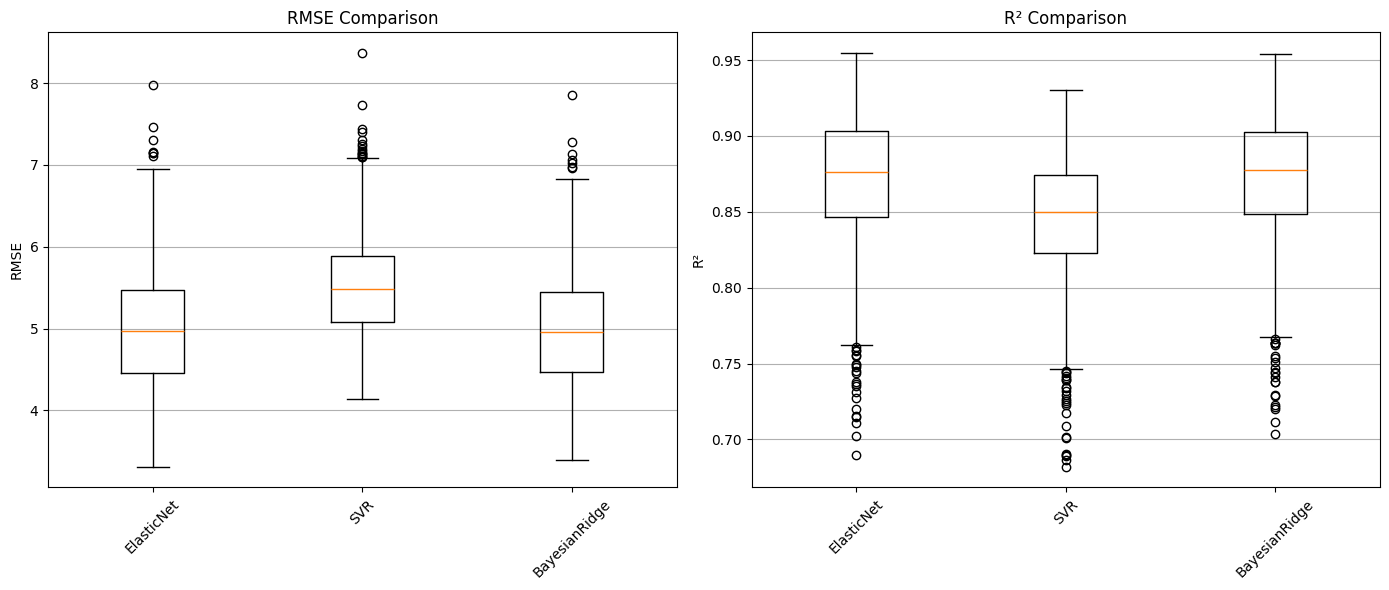

In [7]:
get_comparison_boxplot({
    'ElasticNet':    en_eval_dict,
    'SVR':           svr_eval_dict,
    'BayesianRidge': br_eval_dict,
}, save_path='../figures/tuned_models_comparison_boxplot.png')

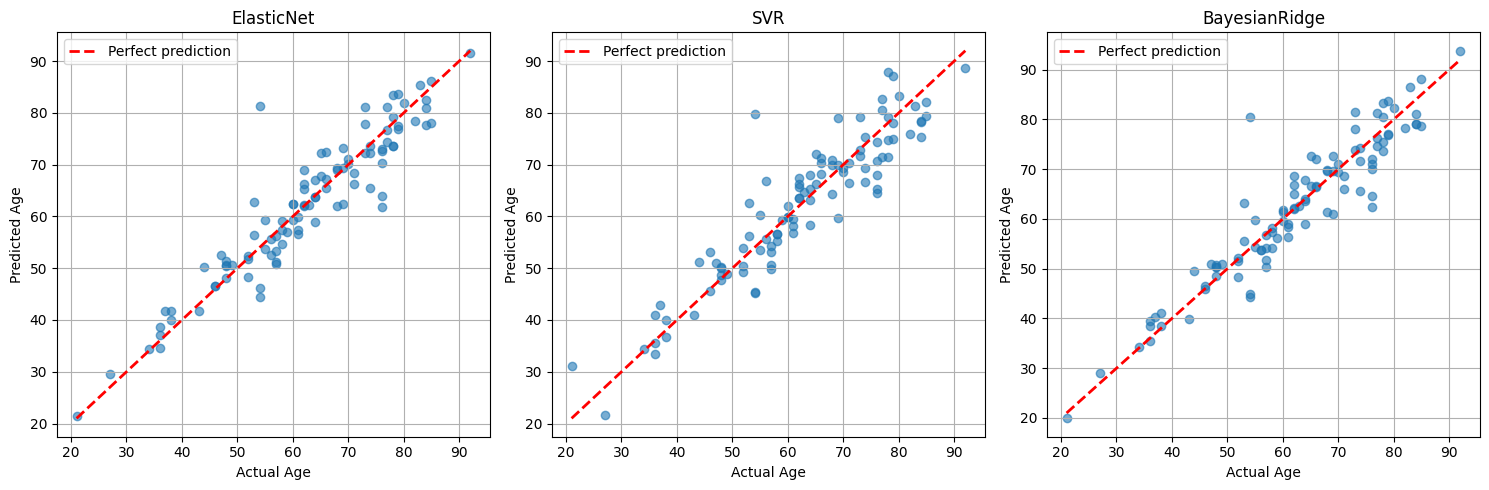

In [8]:
# scatter plots of predicted vs actual age for the three models

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, y_pred) in zip(axes, [
    ('ElasticNet', y_pred_en),
    ('SVR', y_pred_svr),
    ('BayesianRidge', y_pred_br)
]):
    ax.scatter(y_eval, y_pred, alpha=0.6)
    ax.plot([y_eval.min(), y_eval.max()], 
            [y_eval.min(), y_eval.max()], 
            'r--', linewidth=2, label='Perfect prediction')
    ax.set_xlabel('Actual Age')
    ax.set_ylabel('Predicted Age')
    ax.set_title(f'{name}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig('../figures/predicted_vs_actual_age.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 4.3 — Model Selection

**Selected model: BayesianRidge**

Based on the evaluation results, BayesianRidge is selected as the best model, 
with ElasticNet being a very close second (ΔRMSE=0.013, ΔR²=0.001).

**1. Performance (RMSE and CI width)**
BayesianRidge achieves the best RMSE (4.976) and R² (0.872) on the evaluation set,
with a 95% CI of [3.77, 6.50] — slightly narrower than ElasticNet's [3.74, 6.61].
A narrower CI indicates more stable and consistent predictions across bootstrap resamples.
SVR is clearly inferior (RMSE=5.51, R²=0.845) and is eliminated.

**2. Model complexity and overfitting risk**
BayesianRidge is a linear model with automatic relevance determination (ARD) — it 
automatically infers the regularization strength from the data via a fully Bayesian 
treatment of the weights. This makes it less prone to overfitting compared to ElasticNet,
which requires manual tuning of alpha and l1_ratio. Given the relatively small dataset 
size (456 development samples, 197 features), automatic regularization is a significant 
advantage.

**3. Interpretability**
Both BayesianRidge and ElasticNet are linear models, making their coefficients directly 
interpretable as feature weights. Each coefficient represents the contribution of a CpG 
methylation site to the predicted age. BayesianRidge additionally provides uncertainty 
estimates for each prediction, which is valuable in a biological context where quantifying 
prediction confidence is important. The scatter plot confirms that BayesianRidge predictions 
are well-aligned with actual ages across the full range (20-90 years), with no systematic 
bias at extreme ages — unlike SVR which underestimates ages above 70.

**Conclusion**: BayesianRidge offers the best combination of predictive performance, 
automatic regularization, and interpretability for epigenetic age prediction.

In [9]:
# save best model (BayesianRidge) for future use
joblib.dump(best_bayesianridge, '../models/best_model.pkl')

['../models/best_model.pkl']

In [10]:
## Bonus A: Optuna Hyperparameter Optimization ##

from src.functions import optuna_tune_model

# ElasticNet
pipeline_en = Pipeline([
    ('preprocessor', build_num_preprocessor()),
    ('model', ElasticNet())
])
best_en_optuna, study_en = optuna_tune_model(
    'ElasticNet', pipeline_en, X_dev, y_dev, n_trials=40, random_state=42
)

# SVR
pipeline_svr = Pipeline([
    ('preprocessor', build_num_preprocessor()),
    ('model', SVR())
])
best_svr_optuna, study_svr = optuna_tune_model(
    'SVR', pipeline_svr, X_dev, y_dev, n_trials=40, random_state=42
)

# BayesianRidge
pipeline_br = Pipeline([
    ('preprocessor', build_num_preprocessor()),
    ('model', BayesianRidge())
])
best_br_optuna, study_br = optuna_tune_model(
    'BayesianRidge', pipeline_br, X_dev, y_dev, n_trials=40, random_state=42
)

[I 2026-03-23 00:27:27,143] A new study created in memory with name: no-name-31f508a1-f701-4734-ba2e-6a178ada5754



ElasticNet — Best Optuna params: {'alpha': 0.6281680002872636, 'l1_ratio': 0.11185905921700628}
ElasticNet — Best Optuna CV RMSE: 4.6172

SVR — Best Optuna params: {'C': 24.905756987261594, 'epsilon': 0.1, 'kernel': 'rbf'}
SVR — Best Optuna CV RMSE: 5.2633

BayesianRidge — Best Optuna params: {'alpha_1': 0.0003270664319480793, 'alpha_2': 4.598470693285468e-06, 'lambda_1': 0.0009892607189163178, 'lambda_2': 1.229458765312235e-05}
BayesianRidge — Best Optuna CV RMSE: 4.6513


In [11]:
# Head-to-head table: RandomSearch vs Optuna
comparison_tuning = pd.DataFrame({
    'Model':              ['ElasticNet', 'SVR', 'BayesianRidge'],
    'RandomSearch RMSE':  [4.6556, 5.2898, 4.6513],
    'Optuna RMSE':        [4.6172, 5.2633, 4.6513],
    'Delta':              [round(4.6172-4.6556, 4), 
                           round(5.2633-5.2898, 4), 
                           round(4.6513-4.6513, 4)],
    'Winner':             ['Optuna', 'Optuna', 'Tie']
}).set_index('Model')

display(comparison_tuning)

,RandomSearch RMSE,Optuna RMSE,Delta,Winner
Model,,,,
ElasticNet,4.6556,4.6172,-0.0384,Optuna
SVR,5.2898,5.2633,-0.0265,Optuna
BayesianRidge,4.6513,4.6513,0.0000,Tie


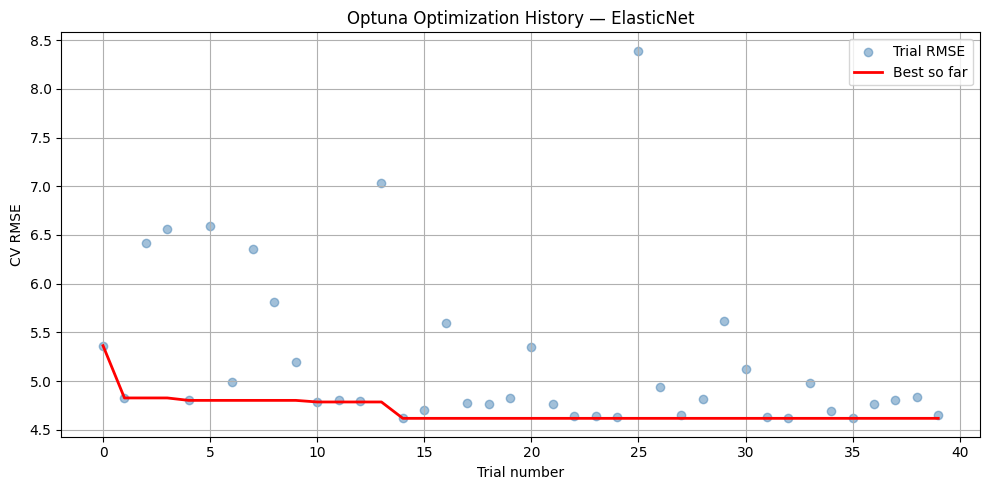

In [13]:
from src.functions import plot_optuna_history

plot_optuna_history(
    study_en, 
    'ElasticNet',
    save_path='../figures/optuna_history_elasticnet.png'
)

## Optuna vs RandomizedSearchCV — Discussion

### Results
Optuna (TPE) achieved marginally better CV RMSE than RandomizedSearchCV for ElasticNet 
(-0.038) and SVR (-0.027), while BayesianRidge converged to identical results (0.000).
The differences are small, suggesting both methods explore the search space adequately 
with 40 trials on this dataset.

### Optimization History (ElasticNet)
The optimization history plot reveals the TPE behavior clearly:
- **Early trials (0-5)**: broad exploration across the search space — high variance in RMSE
- **Mid trials (5-15)**: TPE identifies promising regions and begins to exploit them — 
  the "best so far" line drops steadily
- **Late trials (15-40)**: convergence — most trials cluster near the optimum (~4.6), 
  with occasional exploratory outliers (e.g. trial 25, RMSE=8.4)

### When does Optuna offer a larger advantage?
The results converge to similar values on this dataset because:
1. The search space is relatively small (2-4 hyperparameters per model)
2. 40 trials is sufficient for both methods to find good regions
3. The objective function is relatively smooth

Optuna offers a **larger advantage** when:
- The search space is **high-dimensional** (10+ hyperparameters)
- The objective function has **complex interactions** between hyperparameters
- The budget is **limited** (fewer trials) — TPE finds good regions faster than random search
- Some hyperparameter combinations are **catastrophically bad** — TPE learns to avoid them